In [301]:
# !pip install -q numpy scikit-learn pandas matplotlib seaborn 

In [302]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler

In [303]:
# pip install openpyxl

In [304]:
data = pd.read_excel("ENB2012_data.xlsx")
data.head()

,X1,X2,X3,X4,X5,X6,X7,X8,Y1,Y2
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28


In [305]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X1      768 non-null    float64
 1   X2      768 non-null    float64
 2   X3      768 non-null    float64
 3   X4      768 non-null    float64
 4   X5      768 non-null    float64
 5   X6      768 non-null    int64  
 6   X7      768 non-null    float64
 7   X8      768 non-null    int64  
 8   Y1      768 non-null    float64
 9   Y2      768 non-null    float64
dtypes: float64(8), int64(2)
memory usage: 60.1 KB


In [306]:
# Clean the dataset
df_clean = (
    data.drop(columns=['X6', 'X8'])
    .dropna() # Drop row with missing values
    .reset_index(drop=True) # Reset index after dropping rows
)
df_clean.head(10);

In [307]:
print(data.isna().sum())

X1    0
X2    0
X3    0
X4    0
X5    0
X6    0
X7    0
X8    0
Y1    0
Y2    0
dtype: int64


In [308]:
print("Total missing values:", data.isna().sum().sum())

Total missing values: 0


In [309]:
df_clean.info();

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X1      768 non-null    float64
 1   X2      768 non-null    float64
 2   X3      768 non-null    float64
 3   X4      768 non-null    float64
 4   X5      768 non-null    float64
 5   X7      768 non-null    float64
 6   Y1      768 non-null    float64
 7   Y2      768 non-null    float64
dtypes: float64(8)
memory usage: 48.1 KB


In [310]:
df_clean.describe()

,X1,X2,X3,X4,X5,X7,Y1,Y2
count,768.000000,768.000000,768.000000,768.000000,768.00000,768.000000,768.000000,768.000000
mean,0.764167,671.708333,318.500000,176.604167,5.25000,0.234375,22.307195,24.587760
std,0.105777,88.086116,43.626481,45.165950,1.75114,0.133221,10.090204,9.513306
min,0.620000,514.500000,245.000000,110.250000,3.50000,0.000000,6.010000,10.900000
25%,0.682500,606.375000,294.000000,140.875000,3.50000,0.100000,12.992500,15.620000
50%,0.750000,673.750000,318.500000,183.750000,5.25000,0.250000,18.950000,22.080000
75%,0.830000,741.125000,343.000000,220.500000,7.00000,0.400000,31.667500,33.132500
max,0.980000,808.500000,416.500000,220.500000,7.00000,0.400000,43.100000,48.030000


In [311]:
df_clean.columns.to_list()

['X1', 'X2', 'X3', 'X4', 'X5', 'X7', 'Y1', 'Y2']

In [312]:
TARGET = 'Y1'
predictors = ['X1', 'X2', 'X3', 'X4', 'X5', 'X7']

In [313]:
df_clean[TARGET]

0      15.55
1      15.55
2      15.55
3      15.55
4      20.84
       ...  
763    17.88
764    16.54
765    16.44
766    16.48
767    16.64
Name: Y1, Length: 768, dtype: float64

In [314]:
df_clean[predictors].describe()

,X1,X2,X3,X4,X5,X7
count,768.000000,768.000000,768.000000,768.000000,768.00000,768.000000
mean,0.764167,671.708333,318.500000,176.604167,5.25000,0.234375
std,0.105777,88.086116,43.626481,45.165950,1.75114,0.133221
min,0.620000,514.500000,245.000000,110.250000,3.50000,0.000000
25%,0.682500,606.375000,294.000000,140.875000,3.50000,0.100000
50%,0.750000,673.750000,318.500000,183.750000,5.25000,0.250000
75%,0.830000,741.125000,343.000000,220.500000,7.00000,0.400000
max,0.980000,808.500000,416.500000,220.500000,7.00000,0.400000


In [315]:
x = df_clean[predictors]
y = df_clean[TARGET]
print("Full dataframe shape:", df_clean.shape)
print("Predictor matrix shape:", x.shape)
print("Target shape:", y.shape)

Full dataframe shape: (768, 8)
Predictor matrix shape: (768, 6)
Target shape: (768,)


EDA

1. Univariate Analysis

In [316]:
eda_df = df_clean[[TARGET] + predictors]
eda_df

,Y1,X1,X2,X3,X4,X5,X7
0,15.55,0.98,514.5,294.0,110.25,7.0,0.0
1,15.55,0.98,514.5,294.0,110.25,7.0,0.0
2,15.55,0.98,514.5,294.0,110.25,7.0,0.0
3,15.55,0.98,514.5,294.0,110.25,7.0,0.0
4,20.84,0.90,563.5,318.5,122.50,7.0,0.0
...,...,...,...,...,...,...,...
763,17.88,0.64,784.0,343.0,220.50,3.5,0.4
764,16.54,0.62,808.5,367.5,220.50,3.5,0.4
765,16.44,0.62,808.5,367.5,220.50,3.5,0.4
766,16.48,0.62,808.5,367.5,220.50,3.5,0.4


Univariate Plot 1: histplot

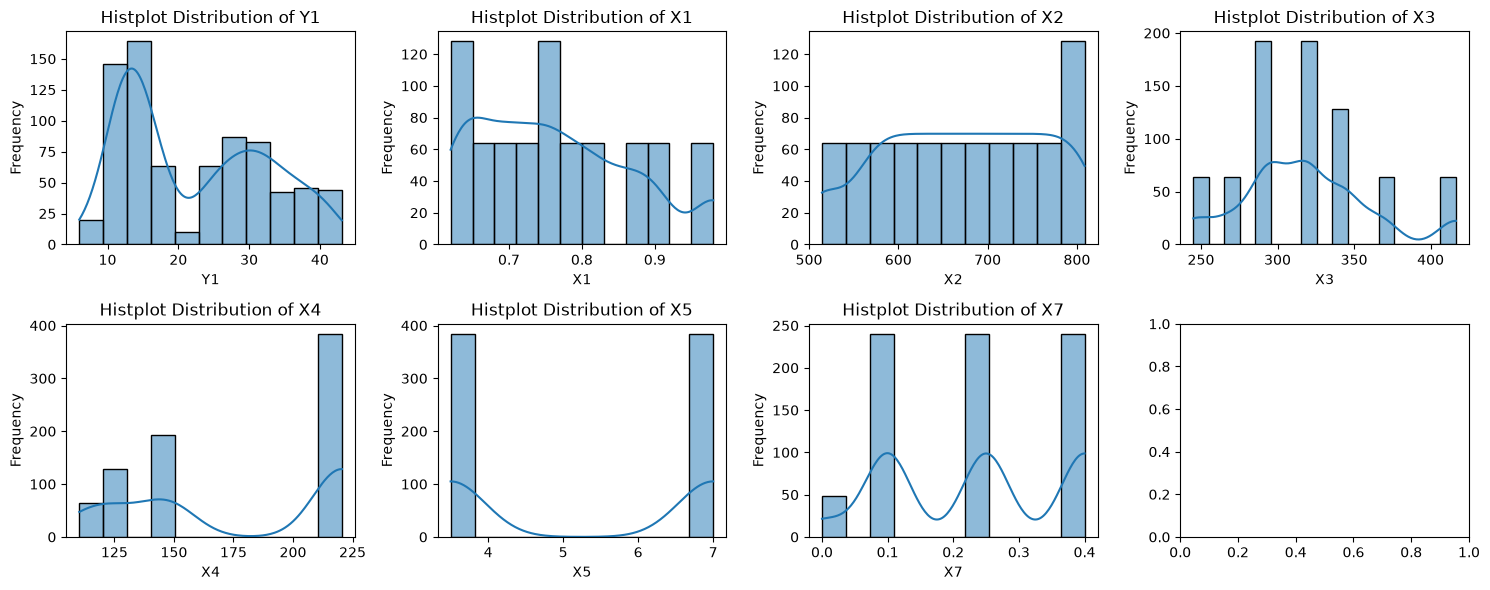

In [317]:
fig, axes = plt.subplots(2, 4, figsize=(15, 6))

axes = axes.ravel()

for i, c in enumerate(eda_df.columns):
    sns.histplot(df_clean[c], ax=axes[i], kde=True)
    axes[i].set_title(f"Histplot Distribution of {c}")
    axes[i].set_xlabel(c)
    axes[i].set_ylabel("Frequency")
    
plt.tight_layout()
plt.show()

Univariate Plot 2: ecdfplot

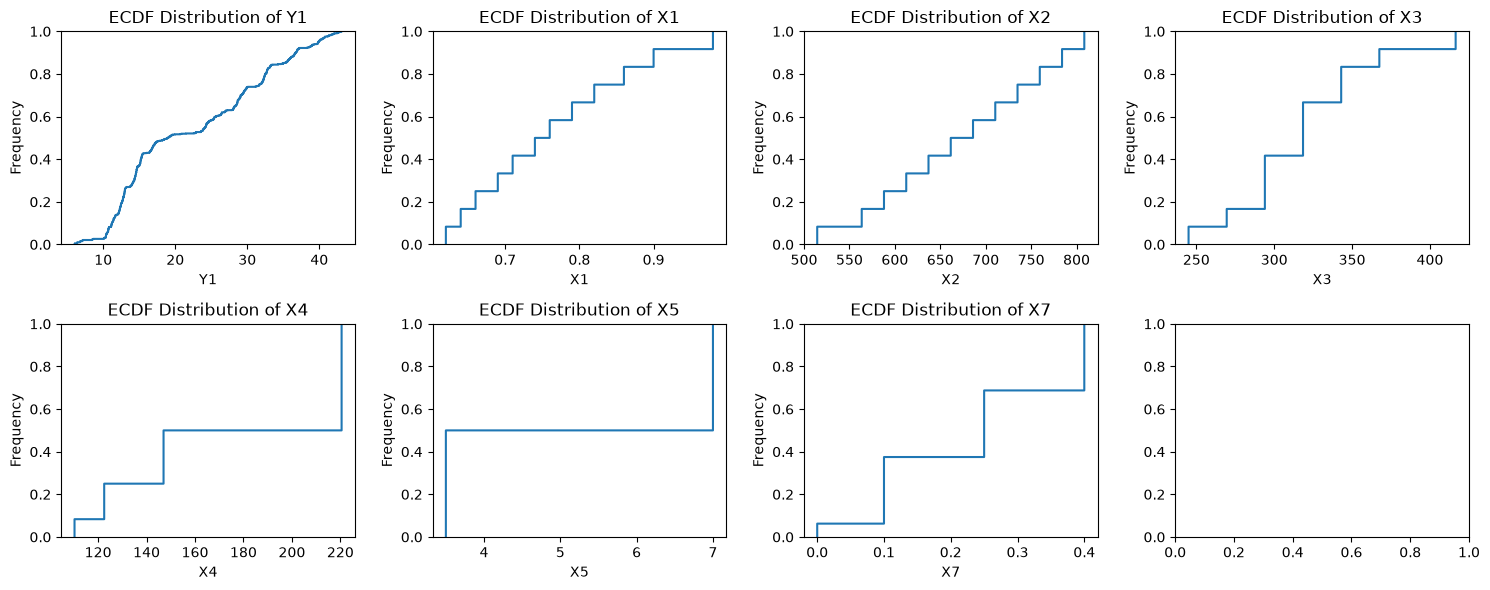

In [318]:
fig, axes = plt.subplots(2,4, figsize=(15, 6))

axes = axes.ravel()

for i, c in enumerate(eda_df.columns):
    sns.ecdfplot(data=eda_df, x=c, ax=axes[i])
    axes[i].set_title(f"ECDF Distribution of {c}")
    axes[i].set_xlabel(c)
    axes[i].set_ylabel("Frequency")
    
plt.tight_layout()
plt.show()

Univariate Plot 3: violinplot

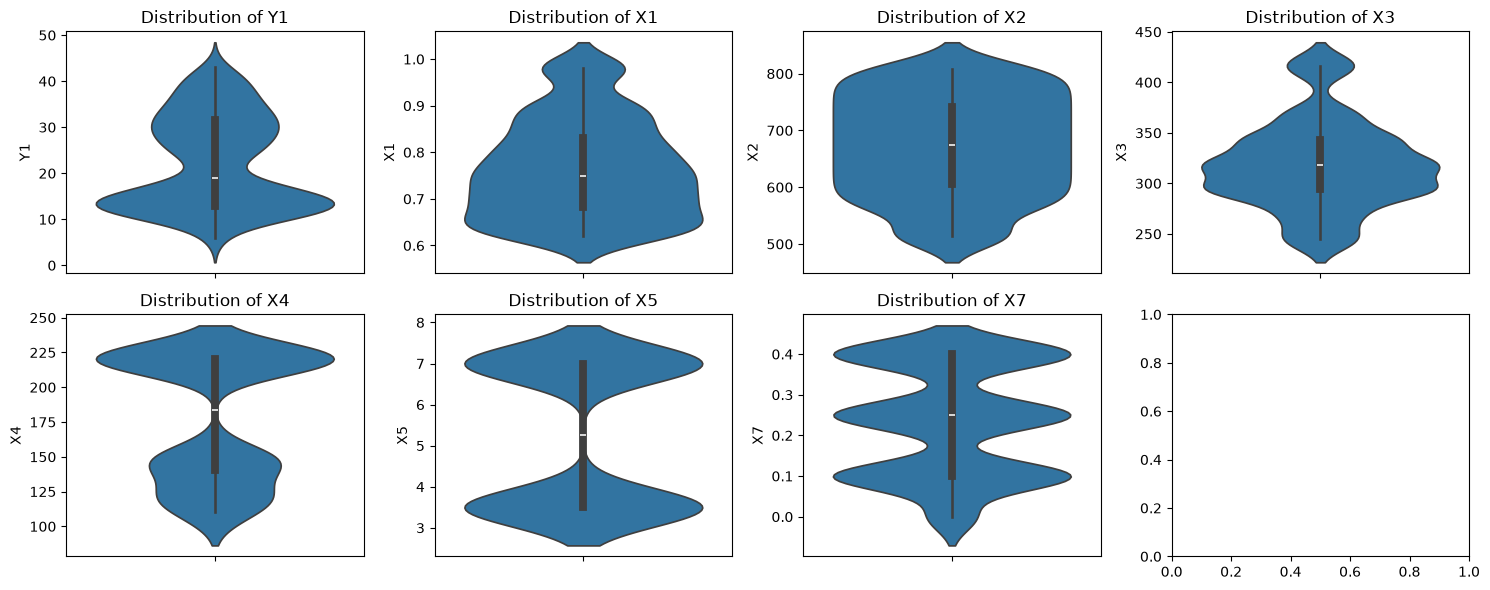

In [319]:
fig, axes = plt.subplots(2,4, figsize=(15, 6))
axes = axes.ravel()
for i, c in enumerate(eda_df.columns):
    sns.violinplot(eda_df[c], ax=axes[i])
    axes[i].set_title(f"Distribution of {c}")
plt.tight_layout()
plt.show()

Univariate Findings:

- Y1 is Right-skewed

2. Bivariate Analysis

Bivariate Plot 1: hexbin

In [320]:
continuous_predictors1 = ["X1", "X2", "X3"]

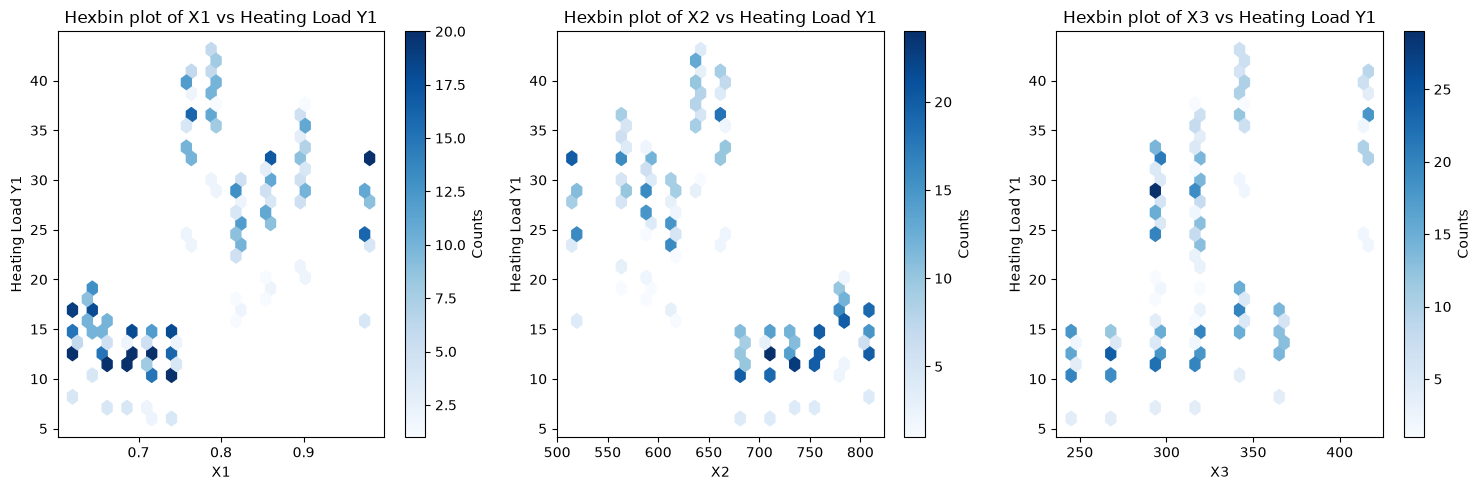

In [321]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, c in zip(axes, continuous_predictors1):

    hb = ax.hexbin(eda_df[c], eda_df[TARGET], gridsize=30, cmap='Blues', mincnt=1)

    ax.set_title(f"Hexbin plot of {c} vs Heating Load {TARGET}")
    ax.set_xlabel(c)
    ax.set_ylabel(f"Heating Load {TARGET}")

    fig.colorbar(hb, ax=ax, label='Counts')
    
plt.tight_layout()
plt.show()

Bivariate Plot 2: violinplot

In [322]:
continuous_predictors2 = ["X4", "X5", "X7"]

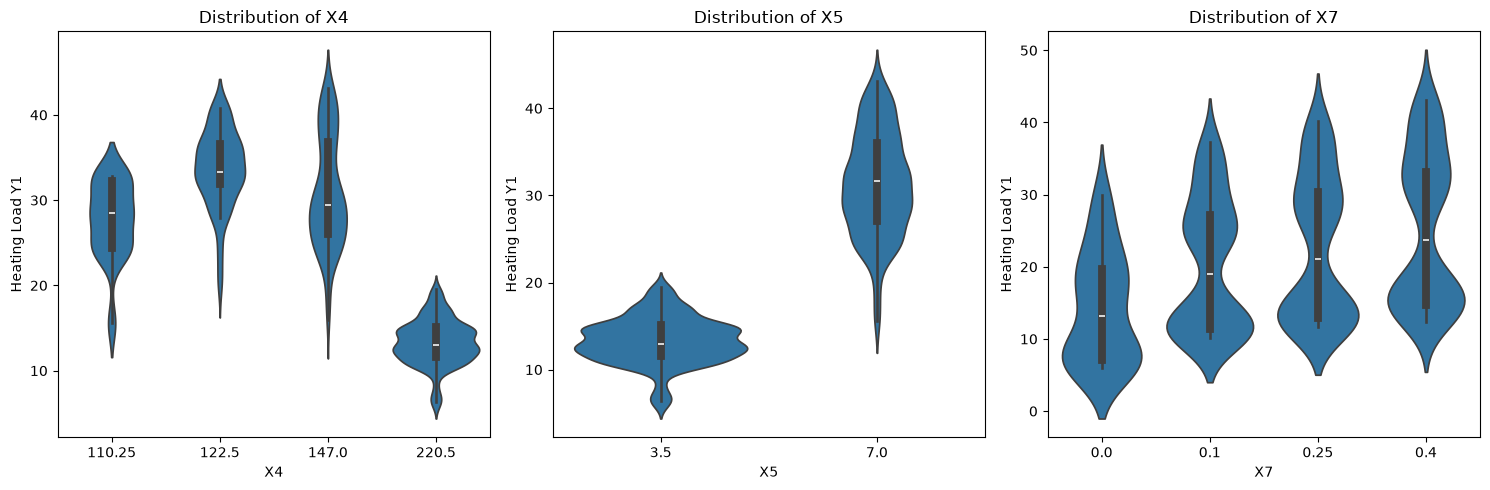

In [323]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, c in zip(axes, continuous_predictors2):
    sns.violinplot(
        data=eda_df, 
        x=c,
        y=TARGET,
        ax=ax)

    ax.set_title(f"Distribution of {c}")
    ax.set_xlabel(c)
    ax.set_ylabel(f"Heating Load {TARGET}")

plt.tight_layout()
plt.show()

Bivariate Findings:

- Sharp, clean split: at X5=3.5 the Y1 violin is tight and low (median around 13, IQR roughly 10–15); at X5=7.0 the violin shifts up and widens.
- Y1 is fairly similar and high across X4 = 110.25, 122.5, 147.0 (medians ≈28–33), then drops sharply at X4 = 220.5 (median around 13, tight low-spread violin).


3. Correlation Analysis

Correlation Plot 1: Ranked correlation bar chart

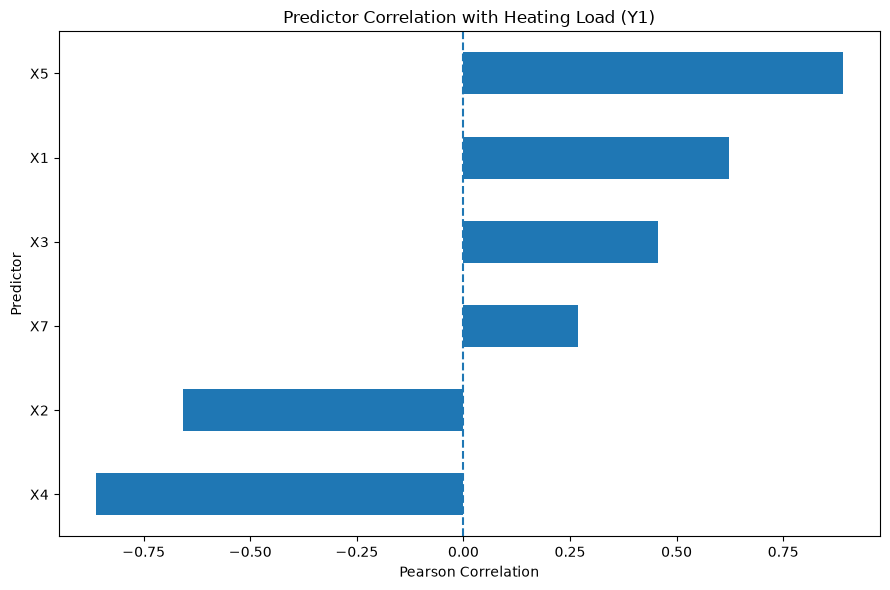

In [324]:
corr_target = (
    eda_df.corr(numeric_only=True)["Y1"]
    .drop("Y1")
    .sort_values()
)

plt.figure(figsize=(9, 6))

corr_target.plot(kind="barh")

plt.axvline(
    0,
    linestyle="--"
)

plt.xlabel("Pearson Correlation")
plt.ylabel("Predictor")
plt.title("Predictor Correlation with Heating Load (Y1)")

plt.tight_layout()
plt.show()

Correlation Plot 2: Clustermap

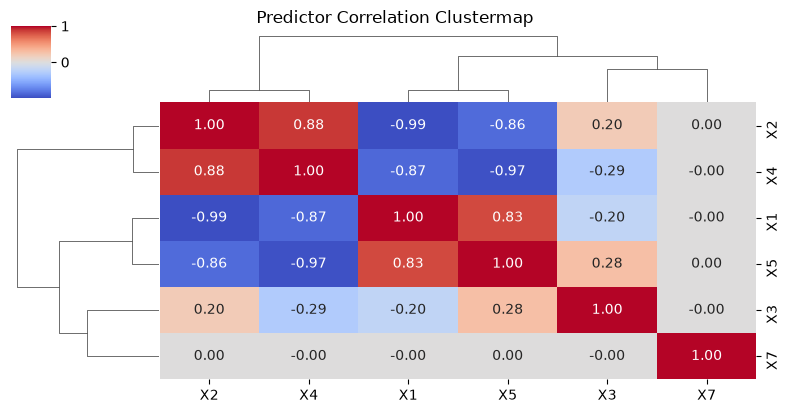

In [325]:
predictor_corr = x.corr()

sns.clustermap(
    predictor_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    figsize=(8, 4)
)

plt.suptitle(
    "Predictor Correlation Clustermap",
    y=1.02
)

plt.show()

Correlation Analysis Findings:

- X2 and X1 have an extremely strong negative correlation (r = -0.99), while X4 and X5 also show a very strong negative correlation (r = -0.97). These indicate substantial redundancy among these predictors.
- X2 and X4 have a strong positive correlation (r = 0.88), while X1 and X5 have a strong positive correlation (r = 0.83). This further confirms that the predictors form highly correlated groups.
- X3 has relatively weak relationships with the other predictors (correlations range from -0.29 to 0.28)
- X7 has no linear correlation with the other predictors (r = 0.00), indicating that it is largely independent of the remaining predictors.

Train & evaluate a multiple linear regression

In [326]:
# Train: Test = 70:30
# For large datasets, you can use 99:1 split. For small datasets, you can use 60:40 or 50:50 split.

train_size = 0.75
test_size = 0.25

x_train, x_test, y_train, y_test = train_test_split(x, y, train_size=train_size, test_size=test_size, random_state=42)

In [327]:
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((576, 6), (192, 6), (576,), (192,))

In [328]:
# Train the model
model = LinearRegression()
model.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](6,)","[-64.91, -0.06, 0.04, -0.05, 4.01, 20.21]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](6,)","['X1','X2','X3','X4','X5','X7']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,86.25
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,6
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(5)


In [329]:
model.coef_.tolist()

[-64.90652106846956,
 -0.06453954636745377,
 0.03847914762721087,
 -0.0515093470250766,
 4.00559090142297,
 20.206911628078462]

In [330]:
print("Intercept:", model.intercept_)

Intercept: 86.2482675999346


In [331]:
coefficients = pd.DataFrame({
    "Feature": eda_df.columns[1:],
    "coefficients": model.coef_.tolist()
    })
coefficients

,Feature,coefficients
0,X1,-64.906521
1,X2,-0.064540
2,X3,0.038479
3,X4,-0.051509
4,X5,4.005591
5,X7,20.206912


In [332]:
Y_train_pred = model.predict(x_train)
Y_train_pred

array([37.03393586,  8.05315267, 32.57776276, 32.57776276, 25.12807171,
       13.05255593, 28.15910846, 11.33023505, 15.42394202, 33.53197873,
       18.71160984, 29.31126582,  9.96919454, 34.30008364, 28.23801015,
       28.15910846, 26.28022908, 13.05255593, 34.30008364, 17.39230854,
       18.71160984, 31.1901452 ,  6.03246151, 13.05255593, 27.46990524,
       29.31126582, 31.2690469 , 14.36127179, 28.23801015, 10.02151918,
       25.12807171, 32.57776276, 18.05195919, 15.42394202, 18.05195919,
       27.46990524, 32.34230257, 15.02092244, 31.2690469 , 15.6805731 ,
       11.9898857 , 30.50094199, 35.6087995 , 27.52603485, 35.6087995 ,
       12.64953635, 14.36127179,  8.05315267, 31.1901452 , 10.02151918,
       28.23801015, 32.34230257, 34.30008364,  7.34117737, 15.6805731 ,
       40.0649726 , 15.42394202, 37.03393586, 15.6805731 , 11.33023505,
       32.34230257, 33.53197873, 13.05255593,  9.36186853, 29.31126582,
       18.71160984, 18.05195919, 18.71160984, 12.39290528, 16.08

In [333]:
Y_test_pred = model.predict(x_test)
Y_test_pred

array([18.71160984, 14.36127179, 31.1901452 , 35.6087995 , 15.02092244,
       28.23801015, 25.12807171, 28.15910846, 18.05195919, 27.46990524,
       18.05195919, 34.00289911, 27.46990524,  8.05315267, 18.05195919,
       37.03393586, 37.03393586, 11.08418941, 15.42394202, 34.00289911,
       34.30008364, 35.6087995 , 11.33023505, 29.54672602, 11.9898857 ,
       29.54672602, 33.53197873, 34.30008364, 15.02092244, 15.6805731 ,
        8.05315267, 11.08418941, 15.02092244, 31.2690469 , 29.54672602,
       28.15910846, 31.1901452 , 29.54672602, 33.53197873,  9.36186853,
       28.15910846, 11.08418941,  7.34117737, 32.34230257,  8.00082802,
        7.34117737,  9.30954388,  9.36186853, 29.31126582, 30.50094199,
       33.53197873, 14.36127179, 14.36127179, 32.57776276, 12.39290528,
       11.9898857 , 11.08418941, 31.2690469 , 40.0649726 , 37.03393586,
       16.08359267, 18.71160984, 14.36127179, 28.23801015, 28.15910846,
       29.54672602, 29.54672602, 11.33023505, 12.64953635, 11.08

Calculate R²

In [334]:
train_r2 = r2_score(y_train, Y_train_pred)
test_r2 = r2_score(y_test, Y_test_pred)
print("Train R²:", train_r2)
print("Test R²:", test_r2)

Train R²: 0.915034156731779
Test R²: 0.9149801212043022


Calculate RMSE (Root Mean Squared Error)

In [335]:
train_rmse = np.sqrt(mean_squared_error(y_train, Y_train_pred))
print("Train RMSE:", train_rmse)
test_rmse = np.sqrt(mean_squared_error(y_test, Y_test_pred))
print("Test RMSE:", test_rmse)

Train RMSE: 2.9202392728541597
Test RMSE: 2.9893968281525


Calculate MSE (Mean Squared Error)

In [336]:
mse = mean_squared_error(y_test, Y_test_pred)
print("Mean Squared Error (MSE):", mse)

Mean Squared Error (MSE): 8.93649339616823


Calculate MAE (Mean Absolute Error)

In [337]:
train_mae = mean_absolute_error(y_train, Y_train_pred)
test_mae = mean_absolute_error(y_test, Y_test_pred)
print("Train MAE:", train_mae)
print("Test MAE:", test_mae)

Train MAE: 2.0236003486230607
Test MAE: 2.14706346687954


In [338]:
results = pd.DataFrame({
    'Dataset': ['Train','Test'],
    'RMSE': [train_rmse, test_rmse],
    'MAE': [train_mae, test_mae],
    'R²': [train_r2, test_r2]
})
print(results)

  Dataset      RMSE       MAE        R²
0   Train  2.920239  2.023600  0.915034
1    Test  2.989397  2.147063  0.914980
